In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = '../backend/data/'
print('✅ Libraries loaded!')

✅ Libraries loaded!


## Step 1 — Load Raw Files

In [2]:
# ─── Load ratings.csv ────────────────────────────────────────────────────────
# Columns: userId, movieId, rating, timestamp
ratings_raw = pd.read_csv(os.path.join(DATA_DIR, 'ratings.csv'))
print(f'Ratings shape: {ratings_raw.shape}')
print(f'Columns: {ratings_raw.columns.tolist()}')
ratings_raw.head()

Ratings shape: (100836, 4)
Columns: ['user_id', 'movie_id', 'rating', 'rated_at']


,user_id,movie_id,rating,rated_at
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


In [3]:
# ─── Load movies.csv ─────────────────────────────────────────────────────────
# Columns: movieId, title, genres (pipe-separated string)
movies_raw = pd.read_csv(os.path.join(DATA_DIR, 'movies.csv'))
print(f'Movies shape: {movies_raw.shape}')
print(f'Columns: {movies_raw.columns.tolist()}')
movies_raw.head()

Movies shape: (9742, 7)
Columns: ['movie_id', 'title', 'genres', 'year', 'title_clean', 'rating_count', 'rating_mean']


,movie_id,title,genres,year,title_clean,rating_count,rating_mean
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,Toy Story,215,3.92
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995.0,Jumanji,110,3.43
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0,Grumpier Old Men,52,3.26
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995.0,Waiting to Exhale,7,2.36
4,5,Father of the Bride Part II (1995),Comedy,1995.0,Father of the Bride Part II,49,3.07


## Step 2 — Clean & Structure

In [4]:
# ─── Standardise column names ─────────────────────────────────────────────────
ratings = ratings_raw.rename(columns={
    'userId'   : 'user_id',
    'movieId'  : 'movie_id',
    'timestamp': 'rated_at'
}).copy()
ratings['rated_at'] = pd.to_datetime(ratings['rated_at'], unit='s')

movies = movies_raw.rename(columns={'movieId': 'movie_id'}).copy()

# ─── Extract year from title ──────────────────────────────────────────────────
movies['year']        = movies['title'].str.extract(r'\((\d{4})\)').astype(float)
movies['title_clean'] = movies['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True).str.strip()

# ─── Clean genres ─────────────────────────────────────────────────────────────
# Already pipe-separated — just replace (no genres) with Unknown
movies['genres'] = movies['genres'].replace('(no genres listed)', 'Unknown')

print(f'Ratings : {ratings.shape}')
print(f'Movies  : {movies.shape}')
print(f'Year range: {movies.year.min():.0f} – {movies.year.max():.0f}')
print(f'\nNull check:')
print(movies[['title_clean','year','genres']].isnull().sum())
movies[['movie_id','title_clean','year','genres']].head(10)

Ratings : (100836, 4)
Movies  : (9742, 7)
Year range: 1902 – 2018

Null check:
title_clean     0
year           13
genres          0
dtype: int64


,movie_id,title_clean,year,genres
0,1,Toy Story,1995.0,Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji,1995.0,Adventure|Children|Fantasy
2,3,Grumpier Old Men,1995.0,Comedy|Romance
3,4,Waiting to Exhale,1995.0,Comedy|Drama|Romance
4,5,Father of the Bride Part II,1995.0,Comedy
5,6,Heat,1995.0,Action|Crime|Thriller
6,7,Sabrina,1995.0,Comedy|Romance
7,8,Tom and Huck,1995.0,Adventure|Children
8,9,Sudden Death,1995.0,Action
9,10,GoldenEye,1995.0,Action|Adventure|Thriller


In [5]:
# ─── Merge for combined analysis ──────────────────────────────────────────────
df = ratings.merge(movies[['movie_id','title_clean','year','genres']], on='movie_id', how='left')
print(f'Merged shape: {df.shape}')
df.head()

Merged shape: (100836, 7)


,user_id,movie_id,rating,rated_at,title_clean,year,genres
0,1,1,4.0,2000-07-30 18:45:03,Toy Story,1995.0,Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,2000-07-30 18:20:47,Grumpier Old Men,1995.0,Comedy|Romance
2,1,6,4.0,2000-07-30 18:37:04,Heat,1995.0,Action|Crime|Thriller
3,1,47,5.0,2000-07-30 19:03:35,Seven (a.k.a. Se7en),1995.0,Mystery|Thriller
4,1,50,5.0,2000-07-30 18:48:51,"Usual Suspects, The",1995.0,Crime|Mystery|Thriller


## Step 3 — Ratings Analysis

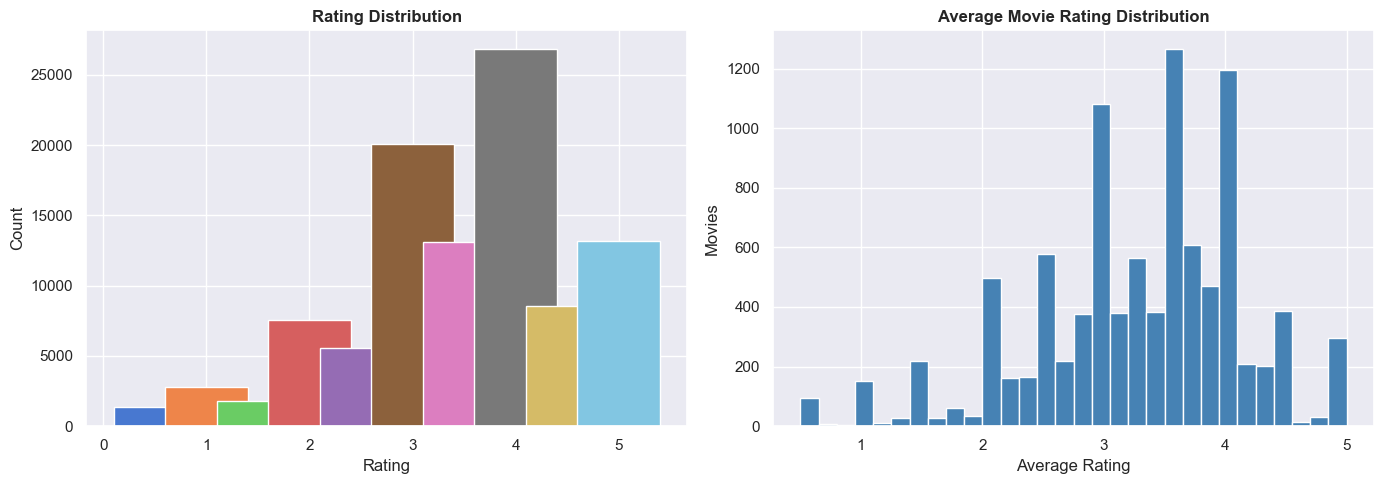

Mean rating: 3.50
Unique users: 610
Unique movies: 9724


In [6]:
# Rating distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rating_counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color=sns.color_palette('muted'))
axes[0].set_title('Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

avg_ratings = df.groupby('movie_id')['rating'].mean()
axes[1].hist(avg_ratings, bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Average Movie Rating Distribution', fontweight='bold')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Movies')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'eda_rating_distribution.png'), bbox_inches='tight')
plt.show()
print(f'Mean rating: {ratings.rating.mean():.2f}')
print(f'Unique users: {ratings.user_id.nunique()}')
print(f'Unique movies: {ratings.movie_id.nunique()}')

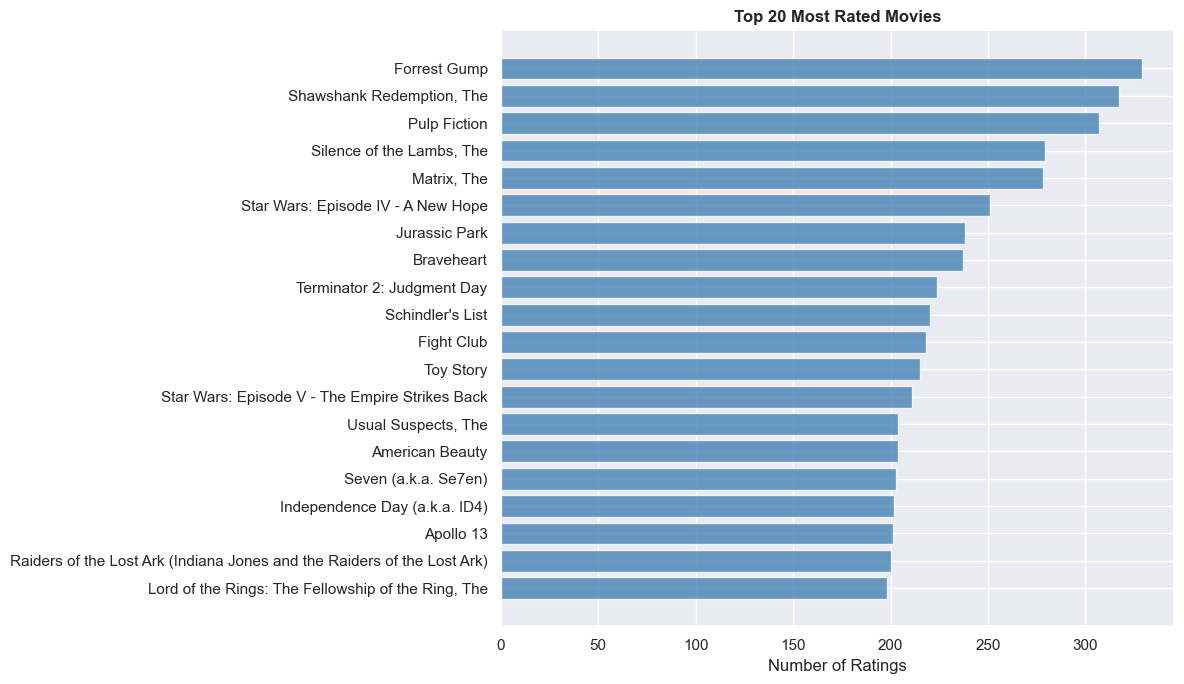

In [7]:
# Top 20 most rated movies
most_rated = (
    df.groupby('title_clean')['rating']
    .agg(count='count', mean='mean')
    .sort_values('count', ascending=False)
    .head(20).reset_index()
)
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(most_rated['title_clean'][::-1], most_rated['count'][::-1], color='steelblue', alpha=0.8)
ax.set_title('Top 20 Most Rated Movies', fontweight='bold')
ax.set_xlabel('Number of Ratings')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'eda_most_rated.png'), bbox_inches='tight')
plt.show()

## Step 4 — Genre Analysis

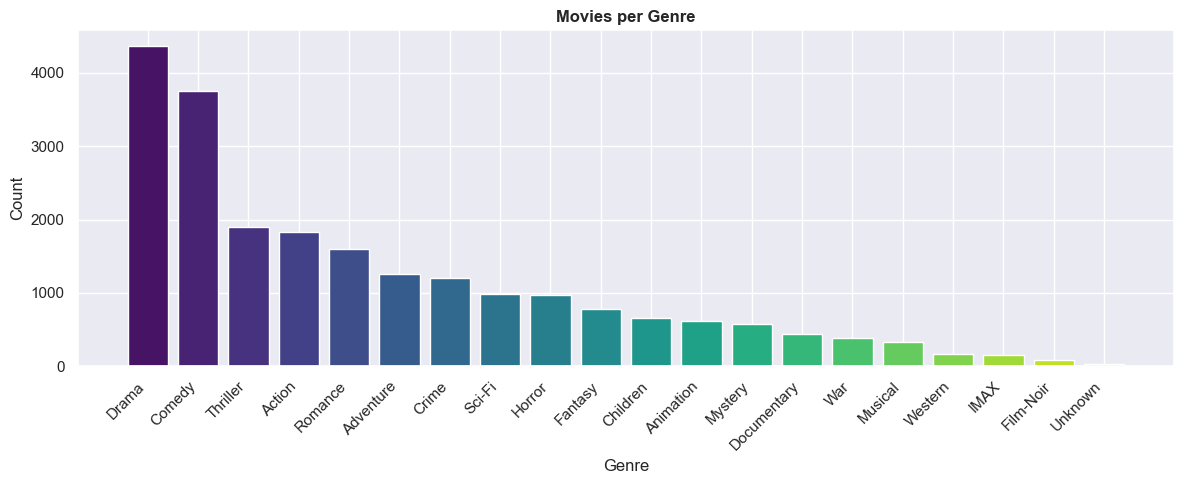

In [8]:
# Explode genres and count
genre_exploded = movies.assign(genre=movies['genres'].str.split('|')).explode('genre')
genre_counts   = genre_exploded['genre'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(genre_counts.index, genre_counts.values, color=sns.color_palette('viridis', len(genre_counts)))
ax.set_title('Movies per Genre', fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'eda_genre_counts.png'), bbox_inches='tight')
plt.show()

## Step 5 — Year Distribution (should now include modern films)

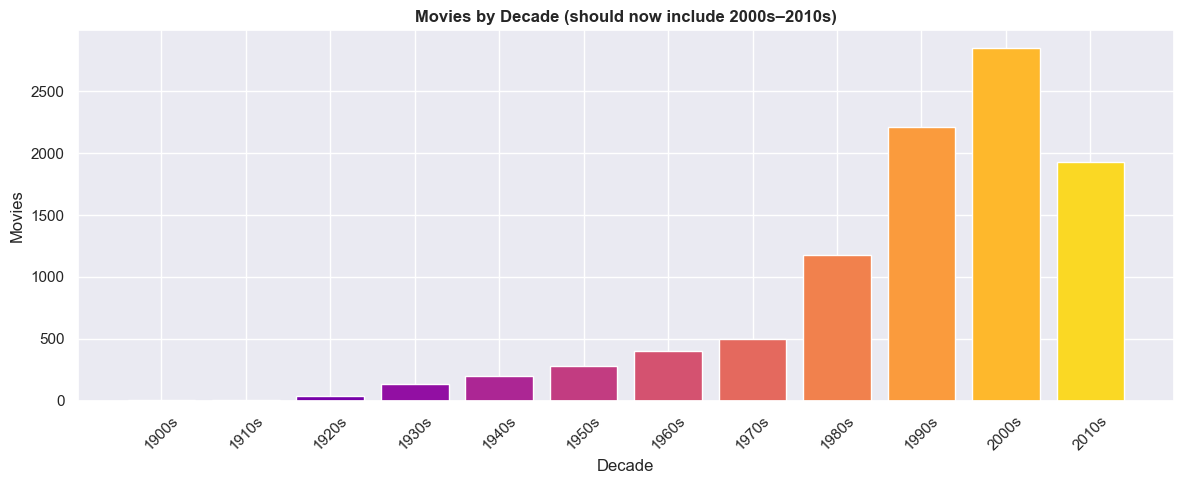

Latest year in dataset: 2018
Films from 2010+: 1931


In [9]:
movies_with_year = movies.dropna(subset=['year']).copy()
movies_with_year['decade'] = (movies_with_year['year'] // 10 * 10).astype(int).astype(str) + 's'
decade_counts = movies_with_year['decade'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(decade_counts.index, decade_counts.values, color=sns.color_palette('plasma', len(decade_counts)))
ax.set_title('Movies by Decade (should now include 2000s–2010s)', fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Movies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Latest year in dataset: {movies_with_year.year.max():.0f}')
print(f'Films from 2010+: {(movies_with_year.year >= 2010).sum()}')

## Step 6 — Sparsity

In [10]:
n_users  = ratings['user_id'].nunique()
n_movies = ratings['movie_id'].nunique()
n_ratings = len(ratings)
sparsity  = 1 - (n_ratings / (n_users * n_movies))

print(f'Users    : {n_users}')
print(f'Movies   : {n_movies}')
print(f'Ratings  : {n_ratings:,}')
print(f'Sparsity : {sparsity:.2%}')

Users    : 610
Movies   : 9724
Ratings  : 100,836
Sparsity : 98.30%


## Step 7 — Save Cleaned CSVs

In [12]:
# Drop old rating columns if they exist (from previous runs)
movies = movies.drop(columns=['rating_mean', 'rating_count'], errors='ignore')

# Add fresh rating stats
movie_stats = (
    ratings.groupby('movie_id')['rating']
    .agg(rating_count='count', rating_mean='mean')
    .reset_index()
)
movies_final = movies.merge(movie_stats, on='movie_id', how='left')
movies_final['rating_mean']  = movies_final['rating_mean'].round(2).fillna(0)
movies_final['rating_count'] = movies_final['rating_count'].fillna(0).astype(int)

movies_final.to_csv(os.path.join(DATA_DIR, 'movies.csv'), index=False)
print(f'✅ Saved movies.csv — {len(movies_final)} movies')
print(f'   Year range: {movies_final.year.min():.0f} – {movies_final.year.max():.0f}')

ratings_final = ratings[['user_id','movie_id','rating','rated_at']].copy()
ratings_final.to_csv(os.path.join(DATA_DIR, 'ratings.csv'), index=False)
print(f'✅ Saved ratings.csv — {len(ratings_final):,} ratings')

movies_final[['movie_id','title_clean','year','genres','rating_mean','rating_count']].head(10)

✅ Saved movies.csv — 9742 movies
   Year range: 1902 – 2018
✅ Saved ratings.csv — 100,836 ratings


,movie_id,title_clean,year,genres,rating_mean,rating_count
0,1,Toy Story,1995.0,Adventure|Animation|Children|Comedy|Fantasy,3.92,215
1,2,Jumanji,1995.0,Adventure|Children|Fantasy,3.43,110
2,3,Grumpier Old Men,1995.0,Comedy|Romance,3.26,52
3,4,Waiting to Exhale,1995.0,Comedy|Drama|Romance,2.36,7
4,5,Father of the Bride Part II,1995.0,Comedy,3.07,49
5,6,Heat,1995.0,Action|Crime|Thriller,3.95,102
6,7,Sabrina,1995.0,Comedy|Romance,3.19,54
7,8,Tom and Huck,1995.0,Adventure|Children,2.88,8
8,9,Sudden Death,1995.0,Action,3.12,16
9,10,GoldenEye,1995.0,Action|Adventure|Thriller,3.50,132
